In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("All libraries loaded!")

All libraries loaded!


In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

print("Rows & Columns:", df.shape)
print(df.head(3))

Rows & Columns: (9994, 21)
   Row ID        Order ID Order Date   Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
1       2  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
2       3  CA-2016-138688  6/12/2016   6/16/2016  Second Class    DV-13045   

     Customer Name    Segment        Country         City  ... Postal Code  \
0      Claire Gute   Consumer  United States    Henderson  ...       42420   
1      Claire Gute   Consumer  United States    Henderson  ...       42420   
2  Darrin Van Huff  Corporate  United States  Los Angeles  ...       90036   

   Region       Product ID         Category Sub-Category  \
0   South  FUR-BO-10001798        Furniture    Bookcases   
1   South  FUR-CH-10000454        Furniture       Chairs   
2    West  OFF-LA-10000240  Office Supplies       Labels   

                                        Product Name   Sales  Quantity  \
0                  Bush Somerset

In [3]:
df = df[['Order Date', 'Sales']]
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date').reset_index(drop=True)

print(df.head())
print("\nDate range:", df['Order Date'].min(), "to", df['Order Date'].max())

  Order Date    Sales
0 2014-01-03   16.448
1 2014-01-04   11.784
2 2014-01-04  272.736
3 2014-01-04    3.540
4 2014-01-05   19.536

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


In [4]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month'] = monthly['Month'].dt.to_timestamp()

print(monthly.head(10))
print("\nTotal months of data:", len(monthly))

       Month       Sales
0 2014-01-01  14236.8950
1 2014-02-01   4519.8920
2 2014-03-01  55691.0090
3 2014-04-01  28295.3450
4 2014-05-01  23648.2870
5 2014-06-01  34595.1276
6 2014-07-01  33946.3930
7 2014-08-01  27909.4685
8 2014-09-01  81777.3508
9 2014-10-01  31453.3930

Total months of data: 48


In [5]:
monthly['Time']      = range(len(monthly))
monthly['Month_Num'] = monthly['Month'].dt.month
monthly['Quarter']   = monthly['Month'].dt.quarter

print(monthly.head())

       Month      Sales  Time  Month_Num  Quarter
0 2014-01-01  14236.895     0          1        1
1 2014-02-01   4519.892     1          2        1
2 2014-03-01  55691.009     2          3        1
3 2014-04-01  28295.345     3          4        2
4 2014-05-01  23648.287     4          5        2


In [6]:
split = int(len(monthly) * 0.8)

X = monthly[['Time', 'Month_Num', 'Quarter']]
y = monthly['Sales']

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training on {len(X_train)} months")
print(f"Testing on  {len(X_test)} months")

Training on 38 months
Testing on  10 months


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model Trained!")
print(f"Trend: Sales changes by ${model.coef_[0]:.2f} per month")
print(f"Base value (intercept): ${model.intercept_:,.2f}")

✅ Model Trained!
Trend: Sales changes by $476.40 per month
Base value (intercept): $18,695.25


In [8]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  → on average predictions are off by ${mae:,.2f}")
print(f"RMSE → ${rmse:,.2f}")

MAE  → on average predictions are off by $10,602.95
RMSE → $16,094.19


In [9]:
last_time = monthly['Time'].max()
last_month_num = monthly['Month_Num'].iloc[-1]

future_data = []
for i in range(1, 4):
    t = last_time + i
    m = ((last_month_num - 1 + i) % 12) + 1
    q = (m - 1) // 3 + 1
    future_data.append([t, m, q])

future_df = pd.DataFrame(future_data, columns=['Time', 'Month_Num', 'Quarter'])
future_sales = model.predict(future_df)

for i, val in enumerate(future_sales):
    print(f"Month +{i+1} forecast: ${val:,.2f}")

Month +1 forecast: $28,352.86
Month +2 forecast: $41,230.71
Month +3 forecast: $54,108.57


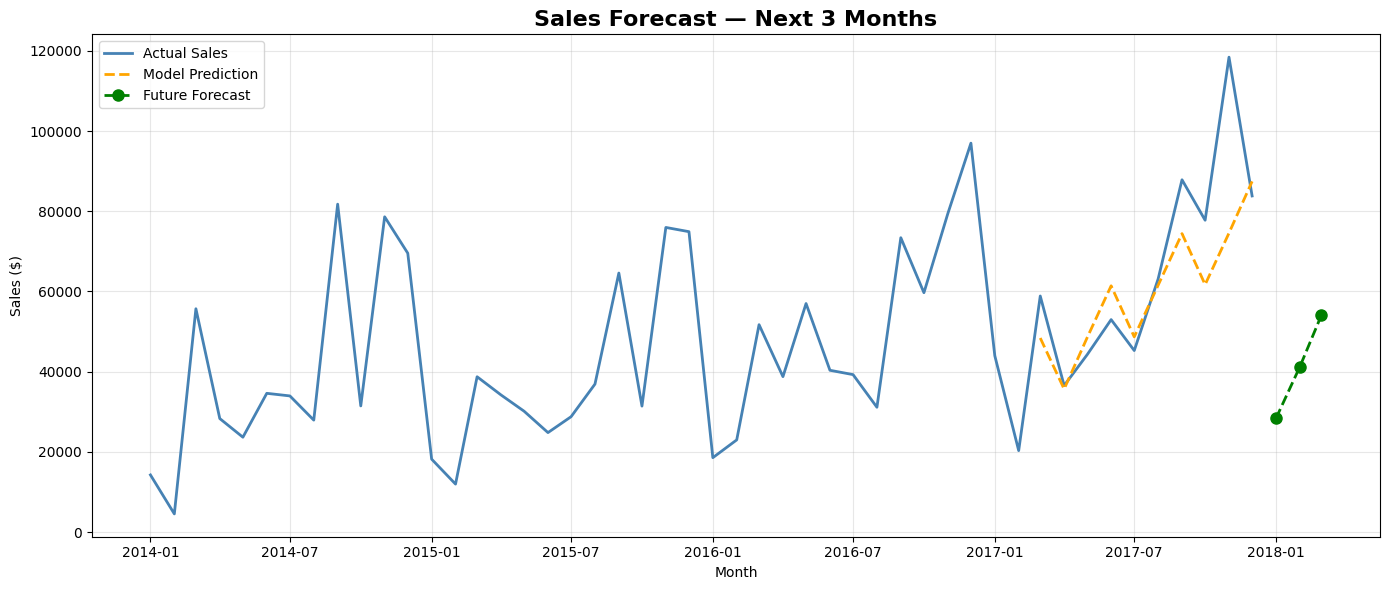

✅ Chart saved as sales_forecast.png


In [10]:
future_dates = pd.date_range(
    start=monthly['Month'].iloc[-1], periods=4, freq='MS')[1:]

plt.figure(figsize=(14, 6))

plt.plot(monthly['Month'], monthly['Sales'],
         color='steelblue', linewidth=2, label='Actual Sales')

plt.plot(monthly['Month'].iloc[split:], y_pred,
         color='orange', linewidth=2,
         linestyle='--', label='Model Prediction')

plt.plot(future_dates, future_sales,
         color='green', linewidth=2,
         linestyle='--', marker='o',
         markersize=8, label='Future Forecast')

plt.title('Sales Forecast — Next 3 Months', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150)
plt.show()

print("✅ Chart saved as sales_forecast.png")

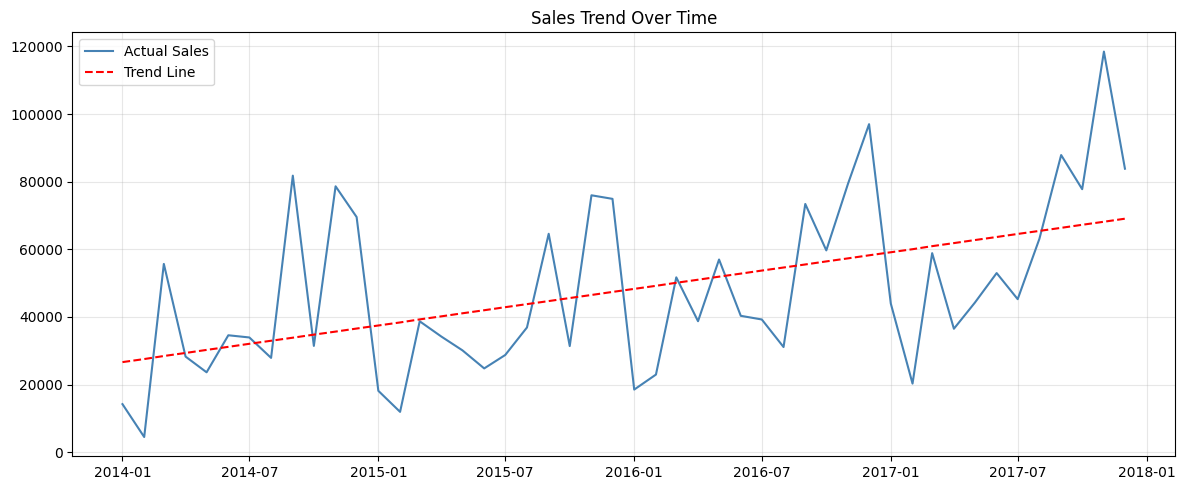

In [11]:
z = np.polyfit(monthly['Time'], monthly['Sales'], 1)
p = np.poly1d(z)

plt.figure(figsize=(12,5))
plt.plot(monthly['Month'], monthly['Sales'], color='steelblue', label='Actual Sales')
plt.plot(monthly['Month'], p(monthly['Time']), color='red', linestyle='--', label='Trend Line')
plt.title('Sales Trend Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('trend.png', dpi=150)
plt.show()

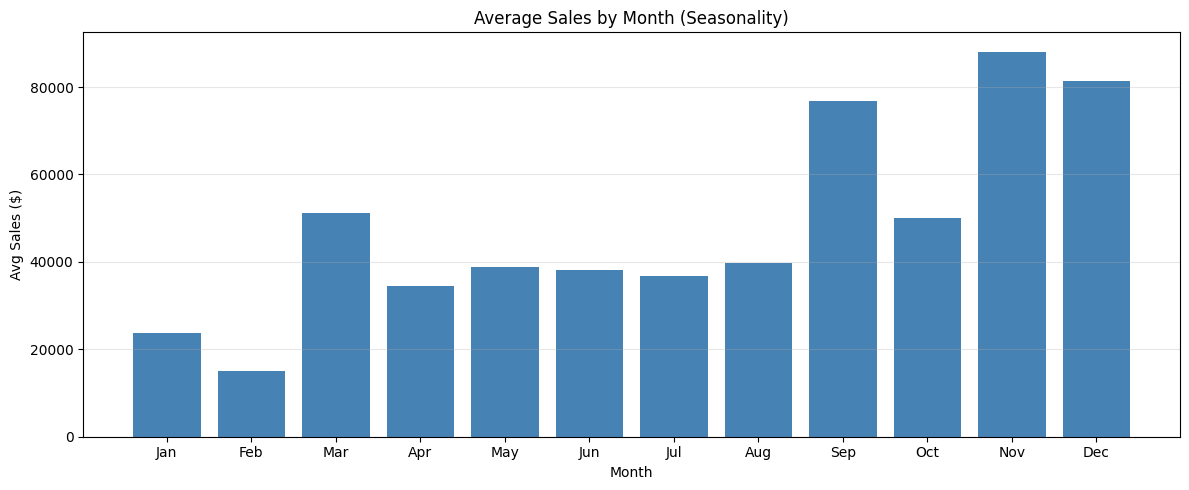

In [12]:
seasonal = monthly.groupby('Month_Num')['Sales'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12,5))
plt.bar(months, seasonal.values, color='steelblue')
plt.title('Average Sales by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Avg Sales ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('seasonality.png', dpi=150)
plt.show()

In [13]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"Model Accuracy (R² Score): {r2:.2%}")

Model Accuracy (R² Score): 54.38%


In [14]:
print("=" * 50)
print("       SALES FORECAST BUSINESS SUMMARY")
print("=" * 50)
print(f"📅 Data Period   : {monthly['Month'].iloc[0].strftime('%b %Y')} → {monthly['Month'].iloc[-1].strftime('%b %Y')}")
print(f"📈 Monthly Trend : ${model.coef_[0]:,.2f} growth per month")
print(f"🎯 Model Accuracy: {r2:.2%} (R² Score)")
print(f"📉 Avg Error     : ${mae:,.2f} (MAE)")
print("-" * 50)
print("🔮 NEXT 3 MONTHS FORECAST:")
for i, val in enumerate(future_sales):
    print(f"   Month +{i+1}  →  ${val:,.2f}")
print("=" * 50)

       SALES FORECAST BUSINESS SUMMARY
📅 Data Period   : Jan 2014 → Dec 2017
📈 Monthly Trend : $476.40 growth per month
🎯 Model Accuracy: 54.38% (R² Score)
📉 Avg Error     : $10,602.95 (MAE)
--------------------------------------------------
🔮 NEXT 3 MONTHS FORECAST:
   Month +1  →  $28,352.86
   Month +2  →  $41,230.71
   Month +3  →  $54,108.57
